In [ ]:
import sys
import os

In [ ]:
%%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    %cd '/content/drive/MyDrive/structure-loss-classification/'
    %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/g/My Drive/types/"

## Import Relevant Modules from Structure Loss Classification Package

In [ ]:
from lightning_modules.integrated import LitLeNet5, LitVGG16, LitResNet18
from utils.utils import get_category_names, load_targets, get_stat_metrics, load_hyperparameter, get_train_val_data
from train.train import train_model, train_with_cv
from visualization.display import display_metrics, process_plot_image
from datasets.datasets import CustomDatasetWrapper
from datasets.data_modules import CustomImageDataModule
from hyperparameter_tuning.tune import HyperParameterTuner
from train.train import incremental_training

## Other Packages

In [ ]:
import torch
import torchvision.transforms as transforms
from ray import tune
import json
import glob

In [ ]:
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, random_split

## Transformations

In [ ]:
toTensorAndNormalize = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((244, 244)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],  # mean
                         [0.5, 0.5, 0.5]  # std
                         )
])

## Define Classification Task

In [ ]:
classification_mode = "only_bad"

In [ ]:
task = {
    'binary': 2,
    'only_bad': 3,
    'all': 4
}

num_classes = task[classification_mode]

In [ ]:
dataset = CustomDatasetWrapper(
    root_dir=my_local_data,
    classification_mode=classification_mode,
    transform=toTensorAndNormalize,
)

In [ ]:
targets = dataset.get_all_labels() #load_targets(dataset)

In [ ]:
train_dataset, val_dataset = get_train_val_data(dataset, targets)

In [ ]:
datamodule = CustomImageDataModule(train_dataset, val_dataset)

In [ ]:
categories = get_category_names(dataset)
print(categories)

['Diameter\nFluctuations', 'Node Cut', 'Particle Hit']


## Instantiate Lightning Model Class

In [ ]:
model_class = LitLeNet5

In [ ]:
model_class.__name__

'LitLeNet5'

## Training Configuration

In [ ]:
torch.set_float32_matmul_precision('medium')
trainer_config = {
    "accelerator": "gpu",
    "devices": -1,
    "max_epochs": 100,
}
save_dir = f'logdir/pipeline_3/{model_class.__name__}/{classification_mode}/cv'

In [ ]:
# hyperparameters = {'model_params': {'num_classes': 2,
#                                     'size_layer_1': 128,
#                                     'size_layer_2': 64},
#                    'learning_rate': 8.479282111072422e-05,
#                    'batch_size': 16,
#                    'num_workers': 8}

In [ ]:
hyperparameters = load_hyperparameter(classification_mode,
                                   filename = f'logdir/pipeline_1/{model_class.__name__}/hyperparameters_{classification_mode}.json')

In [ ]:
hyperparameters

{'model_params': {'num_classes': 3, 'size_layer_1': 100, 'size_layer_2': 84},
 'learning_rate': 0.0001,
 'batch_size': 64,
 'num_workers': 8}

In [ ]:
def new_inc_training(
    model_class: type,  # Assuming you can instantiate the model with this
    model_params: dict,
    trainer_config: dict,
    data_module,
    save_dir: str,
    initial_ckpt_path: str = None,
    increment_epochs: int = 10,
) -> dict:
    """
    Trains a PyTorch Lightning model incrementally for a number of epochs and continues training incrementally
    until max_epochs is reached or early stopping is triggered.
    """

    model = model_class(model_params)
    max_epochs = trainer_config['max_epochs']
    if initial_ckpt_path:
        # Load the initial checkpoint if provided
        model.load_from_checkpoint(initial_ckpt_path)

    for start_epoch in range(0, max_epochs, increment_epochs):
        # Stop if we're already at max_epochs
        if start_epoch >= max_epochs:
            break

        # Update the trainer configuration for incremental training
        trainer_config_updated = trainer_config.copy()
        trainer_config_updated["max_epochs"] = start_epoch + increment_epochs
        # Set the path to the previous best model if it exists
        ckpt_path = (
            trainer.checkpoint_callback.best_model_path if start_epoch > 0 else None
        )

        print(ckpt_path)
        # Define callbacks

        checkpoint_callback = ModelCheckpoint(
            dirpath=save_dir,
            filename=f"{start_epoch + increment_epochs:02d}-{{val_loss:.2f}}",
            monitor="val_loss",
            save_top_k=1,
            mode="min",
        )

        # Create a new trainer instance
        trainer = pl.Trainer(
            **trainer_config_updated,
            callbacks=checkpoint_callback,
            logger=CSVLogger(save_dir),
            # enable_checkpointing=False,
        )
        torch.set_float32_matmul_precision('medium')

        # Train the model incrementally
        trainer.fit(model, datamodule=data_module, ckpt_path=ckpt_path)

        # Check if early stopping was triggered
        if trainer.should_stop:
            print(f"Training stopped early at epoch {start_epoch}.")
            break




    # At the end of all training rounds, delete all checkpoints except the last one
    if ckpt_path:
        for f in glob.glob(f"{save_dir}/*.ckpt"):
            print(f)
            if f != ckpt_path:
                os.remove(f)

    val_metrics = trainer.callback_metrics
    val_metrics_cpu = {key: val.cpu().item() for key, val in val_metrics.items()}

    return val_metrics_cpu

In [ ]:
!ls $save_dir

ls: cannot access 'logdir/pipeline_3/LitLeNet5/only_bad/cv': No such file or directory


In [ ]:
metrics = new_inc_training(model_class=model_class,
                           model_params=hyperparameters,
                           trainer_config=trainer_config,
                           data_module=datamodule,
                           save_dir = save_dir,
)

None


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:653: Checkpoint directory /content/drive/MyDrive/structure-loss-classification/logdir/pipeline_3/LitLeNet5/only_bad/cv exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type                      | Params
------------------------------------------------------------
0 | accuracy      | MulticlassAccuracy        | 0     
1 | f1_score      | MulticlassF1Score         | 0     
2 | cm            | MulticlassConfusionMatrix | 0     
3 | loss_fn       | CrossEntropy

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


logdir/pipeline_3/LitLeNet5/only_bad/cv/10-val_loss=0.83.ckpt
logdir/pipeline_3/LitLeNet5/only_bad/cv/20-val_loss=0.50.ckpt
logdir/pipeline_3/LitLeNet5/only_bad/cv/30-val_loss=0.40.ckpt
logdir/pipeline_3/LitLeNet5/only_bad/cv/40-val_loss=0.32.ckpt
logdir/pipeline_3/LitLeNet5/only_bad/cv/50-val_loss=0.25.ckpt
logdir/pipeline_3/LitLeNet5/only_bad/cv/70-val_loss=0.24.ckpt
logdir/pipeline_3/LitLeNet5/only_bad/cv/80-val_loss=0.23.ckpt
logdir/pipeline_3/LitLeNet5/only_bad/cv/90-val_loss=0.22.ckpt


In [ ]:
metrics

{'val_loss': 0.4009610414505005,
 'val_accuracy': 0.8684210777282715,
 'val_f1_score': 0.8684210777282715}

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
folder = save_dir+'/lightning_logs/*'
dfs = []

In [ ]:
for folder in glob.glob(folder):
    df=pd.read_csv(f'{folder}/metrics.csv')
    dfs.append(df)

In [ ]:
import matplotlib.colors as mcolors

In [ ]:
titles = {'binary': 'Binary',
          'only_bad': 'Only bad ingots',
          'all': 'All four categories'}

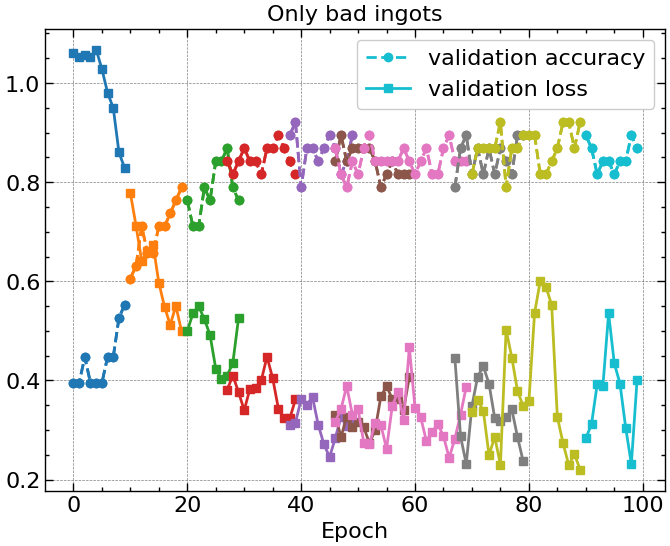

In [ ]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science", "notebook", "grid"])
# Assuming 'dfs' is a list of dataframes and each dataframe has 'epoch' and 'val_accuracy' columns
fig, ax = plt.subplots()
for c, df in enumerate(dfs):
    # Plot the main line with markers
    line1, = ax.plot(df.epoch, df.val_accuracy, '--o',
                    color=list(mcolors.TABLEAU_COLORS.values())[c],
                    label=f'round {str(c+1)}')
    line2, = ax.plot(df.epoch, df.val_accuracy, '--o',
                    color=list(mcolors.TABLEAU_COLORS.values())[c],
                    label=f'validation accuracy')
    line3, = ax.plot(df.epoch, df.val_loss, '-s',
                    color=list(mcolors.TABLEAU_COLORS.values())[c],
                    label=f'validation loss')


    # Find the index of the maximum val_accuracy in the current dataframe
    # max_val_acc_index = df.val_accuracy.idxmax()

    # If this is not the last dataframe, draw a dotted line to the first point of the next dataframe
    # if c < len(dfs) - 1:
    #     next_df = dfs[c + 1]
    #     # Get the point with max val_accuracy from the current dataframe and the first point of the next dataframe
    #     x_values = [df.epoch.iloc[max_val_acc_index], next_df.epoch.iloc[0]]
    #     y_values = [df.val_accuracy.iloc[max_val_acc_index], next_df.val_accuracy.iloc[0]]
    #     # Plot with dotted lines
    #     plt.plot(x_values, y_values, 'o-', color='grey')


ax.legend(loc=(1.005, 0.15))
# ax.add_artist(first_legend)
ax.legend(handles=[line2, line3])
ax.set_title(titles[classification_mode])
ax.set_xlabel('Epoch')
# plt.savefig(f'results/pipeline_3/{model_class.__name__}-{classification_mode}.pdf', bbox_inches='tight')
plt.show()


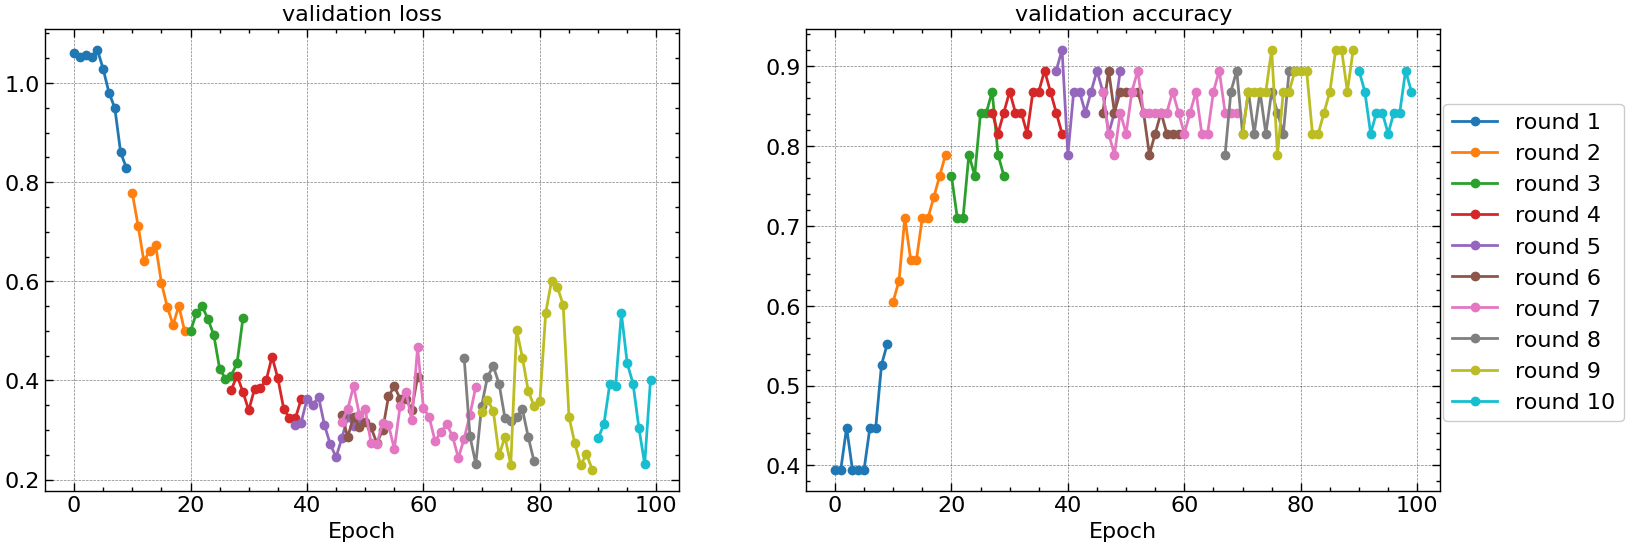

In [ ]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science", "notebook", "grid"])
# Assuming 'dfs' is a list of dataframes and each dataframe has 'epoch' and 'val_accuracy' columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
for c, df in enumerate(dfs):
    # Plot the main line with markers
   ax2.plot(df.epoch, df.val_accuracy, '-o',
                    color=list(mcolors.TABLEAU_COLORS.values())[c],
                    label=f'round {str(c+1)}')

   ax1.plot(df.epoch, df.val_loss, '-o',
                    color=list(mcolors.TABLEAU_COLORS.values())[c],
                   )

    # Find the index of the maximum val_accuracy in the current dataframe
    # max_val_acc_index = df.val_accuracy.idxmax()

    # If this is not the last dataframe, draw a dotted line to the first point of the next dataframe
    # if c < len(dfs) - 1:
    #     next_df = dfs[c + 1]
    #     # Get the point with max val_accuracy from the current dataframe and the first point of the next dataframe
    #     x_values = [df.epoch.iloc[max_val_acc_index], next_df.epoch.iloc[0]]
    #     y_values = [df.val_accuracy.iloc[max_val_acc_index], next_df.val_accuracy.iloc[0]]
    #     # Plot with dotted lines
    #     plt.plot(x_values, y_values, 'o-', color='grey')




ax2.legend(loc=(1.005, 0.15))
ax1.set_title('validation loss')
ax2.set_title('validation accuracy')
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
plt.savefig(f'results/pipeline_3/{model_class.__name__}-{classification_mode}.pdf', bbox_inches='tight')
plt.show()
